## Ready the Test Files (Optional)

### Load the Data

In [11]:
!pip install kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d debeshjha1/polypdb

Dataset URL: https://www.kaggle.com/datasets/debeshjha1/polypdb
License(s): unknown
polypdb.zip: Skipping, found more recently modified local copy (use --force to force download)


In [12]:
!unzip polypdb.zip

Archive:  polypdb.zip
replace PolypDB/PolypDB/PolypDB_center_wise/BKAI/BLI/images/PKHL_15 220831_201026_BN032_027.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


### Create Dataset & Split

In [13]:
import os
import shutil
from sklearn.model_selection import train_test_split
import random

def collect_images():
    """Collect all images and their corresponding labels."""
    images = []
    labels = []

    for modality in modalities:
        image_dir = os.path.join(base_data_dir, modality, "images")
        if os.path.exists(image_dir):
            for img_name in os.listdir(image_dir):
                if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    images.append(os.path.join(image_dir, img_name))
                    labels.append(modality)
        else:
            print(f'image path {image_dir} doesn\'t exist')

    return images, labels

def create_dataset_structure():
    """Create train, val, and test directories with class subfolders."""
    train_dir = os.path.join(output_dir, "train")
    val_dir = os.path.join(output_dir, "val")
    test_dir = os.path.join(output_dir, "test")

    # Create directories if they don't exist
    for dir_path in [train_dir, val_dir, test_dir]:
        for modality in modalities:
            class_dir = os.path.join(dir_path, modality_to_class[modality])
            os.makedirs(class_dir, exist_ok=True)

    return train_dir, val_dir, test_dir

def split_and_copy_images(images, labels):
    """Split dataset into train, val, test and copy images to respective folders."""
    # Split dataset: 70% train, 15% val, 15% test
    train_images, temp_images, train_labels, temp_labels = train_test_split(
        images, labels, test_size=0.3, stratify=labels, random_state=42
    )
    val_images, test_images, val_labels, test_labels = train_test_split(
        temp_images, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
    )

    # Copy images to respective directories
    for split_images, split_labels, split_name in [
        (train_images, train_labels, "train"),
        (val_images, val_labels, "val"),
        (test_images, test_labels, "test")
    ]:
        for img_path, label in zip(split_images, split_labels):
            class_dir = os.path.join(output_dir, split_name, modality_to_class[label])
            shutil.copy(img_path, os.path.join(class_dir, os.path.basename(img_path)))


In [14]:
# Define paths
base_data_dir = "PolypDB/PolypDB/PolypDB_modality_wise"
output_dir = "kaggle/working/colonoscopy_dataset"
modalities = ["BLI", "FICE", "LCI", "NBI", "WLI"]

# Mapping modality names to more readable class names
modality_to_class = {
    "BLI": "BlueLightImaging",
    "FICE": "FlexibleSpectralImagingColorEnhancement",
    "LCI": "LinkedColorImaging",
    "NBI": "NarrowBandImaging",
    "WLI": "WhiteLightImaging"
}

# Collect images and labels
images, labels = collect_images()
print(f"Images and labels collected")

Images and labels collected


In [15]:
# Create directory structure
train_dir, val_dir, test_dir = create_dataset_structure()
print(f"Directories created")

Directories created


In [16]:
# Split and copy images
split_and_copy_images(images, labels)

print(f"Dataset prepared successfully at {output_dir}")
print(f"Train set: {train_dir}")
print(f"Validation set: {val_dir}")
print(f"Test set: {test_dir}")

Dataset prepared successfully at kaggle/working/colonoscopy_dataset
Train set: kaggle/working/colonoscopy_dataset/train
Validation set: kaggle/working/colonoscopy_dataset/val
Test set: kaggle/working/colonoscopy_dataset/test


## Test from files

In [17]:
import os
import numpy
import pandas as pd

import torch
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from torchvision.transforms import v2
import torch.nn as nn


# Extra Libraries for plotting the results
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Testing function from files and with label saving
def test_model(model, test_data_dir, model_paths="best_model.pth", output_file="test_predictions.csv"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # If a list of paths is provided, it's an ensemble model
    if isinstance(model_paths, list):
        ensemble_model = model([MobileNetV2OnlyModel, LightweightEfficientNetModel], model_paths).to(device)
        ensemble_model.eval()
    else:
        model = model.to(device)
        # Load the best model
        model.load_state_dict(torch.load(model_paths, map_location=device))
        model.eval()


    # Create DataLoader from directory
    test_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    test_dataset = datasets.ImageFolder(test_data_dir, transform=test_transforms)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

    correct = 0
    total = 0
    test_loss = 0.0
    criterion = nn.CrossEntropyLoss()
    all_preds = []
    all_labels = []
    filenames = []
    all_confidence = []

    with torch.no_grad():
        for i, (images, labels) in enumerate(test_loader):
            images, labels = images.to(device), labels.to(device)
            if isinstance(model_paths, list):
                confidence, predicted = ensemble_model(images)
                loss = criterion(ensemble_model.model1(images), labels) # Calculate loss based on summed outputs
                all_confidence.extend(confidence.squeeze().cpu().numpy())
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)
                _, predicted = torch.max(outputs.data, 1)
                # For single model, confidence is the softmax probability of the predicted class
                probs = torch.softmax(outputs, dim=1)
                confidence, _ = torch.max(probs, dim=1)
                all_confidence.extend(confidence.cpu().numpy())

            test_loss += loss.item()

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Get filenames for the current batch
            batch_filenames = [test_dataset.samples[i * test_loader.batch_size + j][0] for j in range(images.size(0))]
            filenames.extend(batch_filenames)


    test_loss = test_loss / len(test_loader)
    accuracy = 100 * correct / total
    print(f"Test Loss: {test_loss:.4f}, Accuracy: {accuracy:.2f}%")

    # Save filenames, predicted labels, and confidence to a CSV file
    results_df = pd.DataFrame({'file_name': filenames, 'class_label': [test_dataset.classes[pred] for pred in all_preds], 'confidence': all_confidence})
    results_df.to_csv(output_file, index=False)

    print(f"Test predictions saved to {output_file}")


    # Generate and visualize confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    return accuracy

### Model Zoo

In [18]:
# Define the hybrid model with fallback ViT
class HybridAttentionModel(nn.Module):
    def __init__(self, num_classes=5):
        super(HybridAttentionModel, self).__init__()

        # 1. Lightweight ViT (fallback for global feature extraction)
        self.vit = torchvision.models.vit_b_16(weights = 'ViT_B_16_Weights.DEFAULT')
        self.vit.heads = nn.Identity()  # Remove classification head
        for param in self.vit.parameters():
            param.requires_grad = False  # Freeze ViT parameters
        # Reduce ViT complexity (optional, adjust layers or hidden size if needed)
        self.vit_feature_dim = 768  # Default output dimension for vit_b_16

        # 2. EfficientNet-B0 for local feature extraction
        self.cnn = torchvision.models.efficientnet_b0(weights = 'EfficientNet_B0_Weights.DEFAULT')
        self.cnn.classifier = nn.Identity()  # Remove classification head
        for param in self.cnn.parameters():
            param.requires_grad = False  # Freeze CNN parameters
        self.cnn_feature_dim = 1280  # Output of EfficientNet-B0 before classifier

        # 3. Lightweight Attention Mechanism
        self.attention = nn.MultiheadAttention(embed_dim=self.vit_feature_dim + self.cnn_feature_dim,
                                              num_heads=4, batch_first=True)

        # 4. MLP for classification
        self.mlp = nn.Sequential(
            nn.Linear(self.vit_feature_dim + self.cnn_feature_dim, 256),  # 768 + 1280 = 2048
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
            # nn.Sigmoid()  # Note: Should be removed for CrossEntropyLoss
        )

    def forward(self, x):
        # Global feature extraction with ViT
        vit_features = self.vit(x)  # Shape: (batch_size, 768)

        # Local feature extraction with EfficientNet-B0
        cnn_features = self.cnn(x)  # Shape: (batch_size, 1280)

        # Concatenate features
        combined_features = torch.cat((vit_features, cnn_features), dim=1)  # Shape: (batch_size, 2048)

        # Apply attention mechanism
        attn_output, _ = self.attention(combined_features.unsqueeze(1), combined_features.unsqueeze(1), combined_features.unsqueeze(1))
        attn_output = attn_output.squeeze(1)  # Shape: (batch_size, 2048)

        # Classification with MLP
        output = self.mlp(attn_output)  # Shape: (batch_size, num_classes)
        return output



###########################################################################################################################
# ----------------------------------------------------------------------------------------------------------------------- #
###########################################################################################################################



# Define the hybrid model with MobileNetV2
class MobileNetV2AttentionModel(nn.Module):
    def __init__(self, num_classes=5):
        super(MobileNetV2AttentionModel, self).__init__()

        # 1. Lightweight MobileNetV2 for global feature extraction
        self.mobilenet = torchvision.models.mobilenet_v2(weights = 'MobileNet_V2_Weights.DEFAULT')
        self.mobilenet.classifier = nn.Identity()  # Remove classification head
        for param in self.mobilenet.parameters():
            param.requires_grad = False  # Freeze MobileNet parameters
        self.mobilenet_feature_dim = 1280  # Output dimension for MobileNetV2 before classifier

        # 2. EfficientNet-B0 for local feature extraction
        self.cnn = torchvision.models.efficientnet_b0(weights = 'EfficientNet_B0_Weights.DEFAULT')
        self.cnn.classifier = nn.Identity()  # Remove classification head
        for param in self.cnn.parameters():
            param.requires_grad = False  # Freeze CNN parameters
        self.cnn_feature_dim = 1280  # Output of EfficientNet-B0 before classifier

        # 3. Lightweight Attention Mechanism
        self.attention = nn.MultiheadAttention(embed_dim=self.mobilenet_feature_dim + self.cnn_feature_dim,
                                              num_heads=4, batch_first=True)

        # 4. MLP for classification
        self.mlp = nn.Sequential(
            nn.Linear(self.mobilenet_feature_dim + self.cnn_feature_dim, 256),  # 1280 + 1280 = 2560
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
            # nn.Sigmoid()  # Note: Should be removed for CrossEntropyLoss
        )

    def forward(self, x):
        # Global feature extraction with MobileNetV2
        mobilenet_features = self.mobilenet(x)  # Shape: (batch_size, 1280)

        # Local feature extraction with EfficientNet-B0
        cnn_features = self.cnn(x)  # Shape: (batch_size, 1280)

        # Concatenate features
        combined_features = torch.cat((mobilenet_features, cnn_features), dim=1)  # Shape: (batch_size, 2560)

        # Apply attention mechanism
        attn_output, _ = self.attention(combined_features.unsqueeze(1), combined_features.unsqueeze(1), combined_features.unsqueeze(1))
        attn_output = attn_output.squeeze(1)  # Shape: (batch_size, 2560)

        # Classification with MLP
        output = self.mlp(attn_output)  # Shape: (batch_size, num_classes)
        return output



###########################################################################################################################
# ----------------------------------------------------------------------------------------------------------------------- #
###########################################################################################################################



# Define the hybrid model with MobileNetV2 and a convolutional layer
class MobileNetV2ConvModel(nn.Module):
    def __init__(self, num_classes=5):
        super(MobileNetV2ConvModel, self).__init__()

        # 1. Lightweight MobileNetV2 for global feature extraction
        self.mobilenet = torchvision.models.mobilenet_v2(weights = 'MobileNet_V2_Weights.DEFAULT')
        self.mobilenet.classifier = nn.Identity()  # Remove classification head
        for param in self.mobilenet.parameters():
            param.requires_grad = False  # Freeze MobileNet parameters
        self.mobilenet_feature_dim = 1280  # Output dimension for MobileNetV2 before classifier

        # 2. EfficientNet-B0 for local feature extraction
        self.cnn = torchvision.models.efficientnet_b0(weights = 'EfficientNet_B0_Weights.DEFAULT')
        self.cnn.classifier = nn.Identity()  # Remove classification head
        for param in self.cnn.parameters():
            param.requires_grad = False  # Freeze CNN parameters
        self.cnn_feature_dim = 1280  # Output of EfficientNet-B0 before classifier

        # 3. Convolutional layer
        self.conv = nn.Conv1d(in_channels=self.mobilenet_feature_dim + self.cnn_feature_dim,
                              out_channels=self.mobilenet_feature_dim + self.cnn_feature_dim,
                              kernel_size=1)


        # 4. MLP for classification
        self.mlp = nn.Sequential(
            nn.Linear(self.mobilenet_feature_dim + self.cnn_feature_dim, 256),  # 1280 + 1280 = 2560
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # Global feature extraction with MobileNetV2
        mobilenet_features = self.mobilenet(x)  # Shape: (batch_size, 1280)

        # Local feature extraction with EfficientNet-B0
        cnn_features = self.cnn(x)  # Shape: (batch_size, 1280)

        # Concatenate features
        combined_features = torch.cat((mobilenet_features, cnn_features), dim=1)  # Shape: (batch_size, 2560)

        # Apply convolutional layer
        conv_output = self.conv(combined_features.unsqueeze(2)).squeeze(2) # Shape: (batch_size, 2560)


        # Classification with MLP
        output = self.mlp(conv_output)  # Shape: (batch_size, num_classes)
        return output



###########################################################################################################################
# ----------------------------------------------------------------------------------------------------------------------- #
###########################################################################################################################



# Define the hybrid model with MobileNetV3-small and a convolutional layer
class MobileNetV3ConvModel(nn.Module):
    def __init__(self, num_classes=5):
        super(MobileNetV3ConvModel, self).__init__()

        # 1. Lightweight MobileNetV3 for global feature extraction
        self.mobilenet = torchvision.models.mobilenet_v3_small(weights = 'MobileNet_V3_Small_Weights.DEFAULT')
        self.mobilenet.classifier = nn.Identity()  # Remove classification head
        for param in self.mobilenet.parameters():
            param.requires_grad = False  # Freeze MobileNet parameters
        self.mobilenet_feature_dim = 576  # Output dimension for MobileNetV3-small before classifier

        # 2. EfficientNet-B0 for local feature extraction
        self.cnn = torchvision.models.efficientnet_b0(weights = 'EfficientNet_B0_Weights.DEFAULT')
        self.cnn.classifier = nn.Identity()  # Remove classification head
        for param in self.cnn.parameters():
            param.requires_grad = False  # Freeze CNN parameters
        self.cnn_feature_dim = 1280  # Output of EfficientNet-B0 before classifier

        # 3. Convolutional layer
        self.conv = nn.Conv1d(in_channels=self.mobilenet_feature_dim + self.cnn_feature_dim,
                              out_channels=self.mobilenet_feature_dim + self.cnn_feature_dim,
                              kernel_size=1)


        # 4. MLP for classification
        self.mlp = nn.Sequential(
            nn.Linear(self.mobilenet_feature_dim + self.cnn_feature_dim, 256),  # 576 + 1280 = 1856
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # Global feature extraction with MobileNetV3
        mobilenet_features = self.mobilenet(x)  # Shape: (batch_size, 576)

        # Local feature extraction with EfficientNet-B0
        cnn_features = self.cnn(x)  # Shape: (batch_size, 1280)

        # Concatenate features
        combined_features = torch.cat((mobilenet_features, cnn_features), dim=1)  # Shape: (batch_size, 1856)

        # Apply convolutional layer
        conv_output = self.conv(combined_features.unsqueeze(2)).squeeze(2) # Shape: (batch_size, 1856)


        # Classification with MLP
        output = self.mlp(conv_output)  # Shape: (batch_size, num_classes)
        return output



###########################################################################################################################
# ----------------------------------------------------------------------------------------------------------------------- #
###########################################################################################################################



# Define the lightweight EfficientNet-only model
class LightweightEfficientNetModel(nn.Module):
    def __init__(self, num_classes=5):
        super(LightweightEfficientNetModel, self).__init__()

        # Use EfficientNet-B0 as the backbone (lightweight version)
        self.backbone = torchvision.models.efficientnet_b0(weights='EfficientNet_B0_Weights.DEFAULT')
        self.backbone.classifier = nn.Identity()  # Remove original classifier
        # Freeze most of the backbone parameters to make it lighter
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Only unfreeze the last few layers for fine-tuning
        for param in self.backbone.features[-3:].parameters():
            param.requires_grad = True

        self.backbone_feature_dim = 1280  # EfficientNet-B0 output features

        # Lightweight classification head
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # Global average pooling
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(self.backbone_feature_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # Extract features using EfficientNet backbone
        features = self.backbone.features(x)

        # Apply our custom classifier
        output = self.classifier(features)

        return output



###########################################################################################################################
# ----------------------------------------------------------------------------------------------------------------------- #
###########################################################################################################################



# Define the MobileNetV2-only model
class MobileNetV2OnlyModel(nn.Module):
    def __init__(self, num_classes=5):
        super(MobileNetV2OnlyModel, self).__init__()

        # 1. Lightweight MobileNetV2 for global feature extraction
        self.mobilenet = torchvision.models.mobilenet_v2(weights = 'MobileNet_V2_Weights.DEFAULT')
        self.mobilenet.classifier = nn.Identity()  # Remove classification head
        for param in self.mobilenet.parameters():
            param.requires_grad = False  # Freeze MobileNet parameters

        # Only unfreeze the last few layers for fine-tuning
        # Adjust the number of layers to unfreeze based on experimentation
        for param in self.mobilenet.features[-3:].parameters():
             param.requires_grad = True

        self.mobilenet_feature_dim = 1280  # Output dimension for MobileNetV2 before classifier

        # 2. MLP for classification
        self.mlp = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # Global average pooling
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(self.mobilenet_feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # Global feature extraction with MobileNetV2
        mobilenet_features = self.mobilenet.features(x)  # Shape: (batch_size, 1280)

        # Classification with MLP
        output = self.mlp(mobilenet_features)  # Shape: (batch_size, num_classes)
        return output



###########################################################################################################################
# ----------------------------------------------------------------------------------------------------------------------- #
# ----------------------------------------------------------------------------------------------------------------------- #
# ----------------------------------------------------------------------------------------------------------------------- #
###########################################################################################################################


class EnsembleModel(nn.Module):
    def __init__(self, model_class: list, model_paths: list):
        super(EnsembleModel, self).__init__()
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # Initialize and load the models
        self.model1 = model_class[0]().to(self.device)
        self.model1.load_state_dict(torch.load(model_paths[0], map_location=self.device))
        self.model1.eval()

        self.model2 = model_class[1]().to(self.device)
        self.model2.load_state_dict(torch.load(model_paths[1], map_location=self.device))
        self.model2.eval()

    def forward(self, x):
        # Get predictions from each model
        with torch.no_grad():
            outputs1 = self.model1(x)
            outputs2 = self.model2(x)

        # Sum the outputs (logits)
        sum_outputs = outputs1 + outputs2

        # Get the predicted class label (index with the highest sum of outputs)
        predicted_label = torch.argmax(sum_outputs, dim=1)

        # Calculate confidence probabilities using softmax on the summed outputs
        confidence_probs = torch.softmax(sum_outputs, dim=1)

        # Get the probability of the chosen label
        confidence_score = torch.gather(confidence_probs, 1, predicted_label.unsqueeze(1)).squeeze(1)

        return confidence_score, predicted_label

### Ensemble Test

In [19]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)
# Define the path to the saved model in Google Drive
source_path = "/content/drive/MyDrive/iMIAP-Project/"

# Gather the desired models
model_paths = []
models = ["best_v2only_model", "best_efficientnet_model"]
for i in range(2):
  model_paths.append(source_path + models[i] +'.pth')

Mounted at /content/drive


Test Loss: 0.0247, Accuracy: 99.83%
Test predictions saved to test_predictions.csv


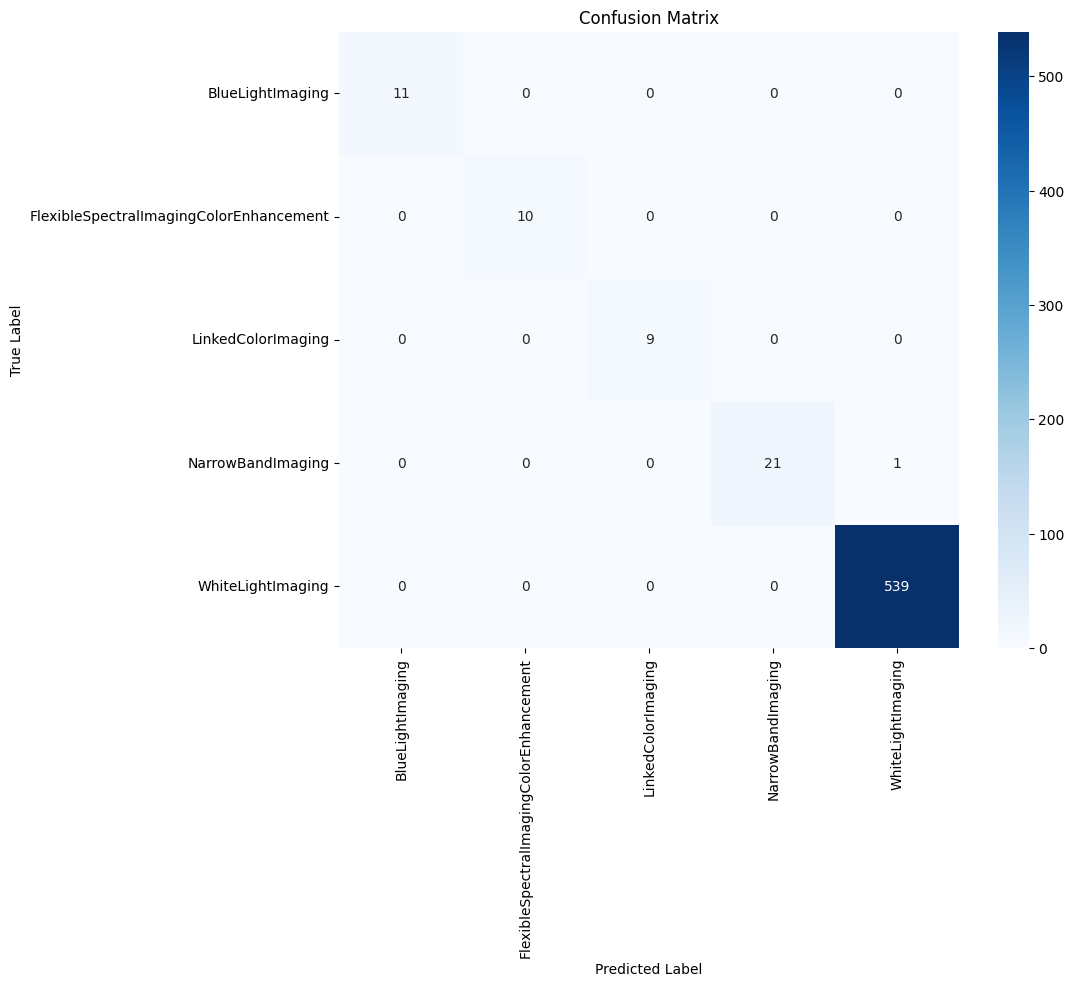

In [20]:
# Define the test data directory
test_data_dir = os.path.join(output_dir, "test")

# Test the ensemble model
test_accuracy = test_model(EnsembleModel, test_data_dir, model_paths=model_paths)

### Single Model

In [23]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)
# Define the path to the saved model in Google Drive
model_path = "/content/drive/MyDrive/iMIAP-Project/best_v2only_model.pth"

# Check if the model file exists
if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model file not found at: {model_path}")

Mounted at /content/drive


Test Loss: 0.0247, Accuracy: 99.49%
Test predictions saved to test_predictions.csv


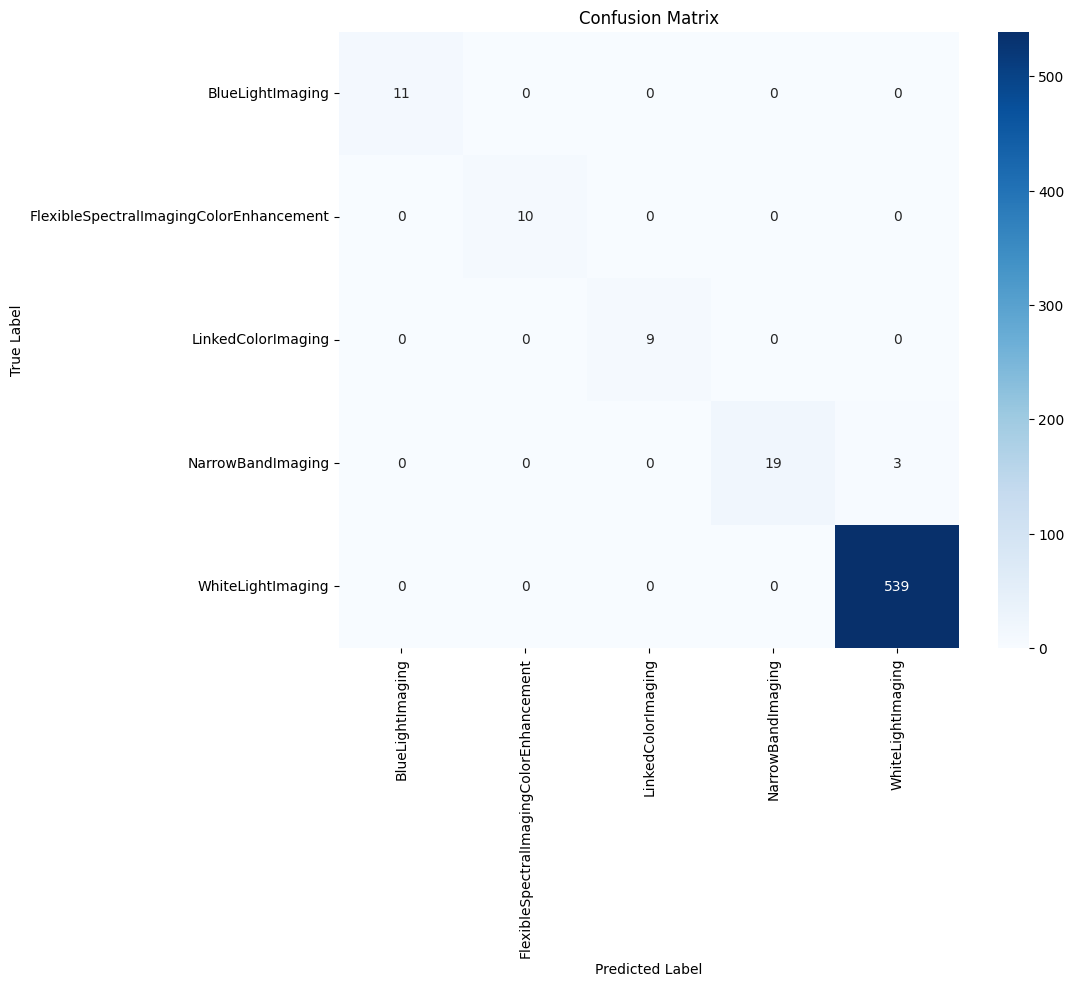

In [24]:
# Define the test data directory
test_data_dir = os.path.join(output_dir, "test")

# Initialize the desired model
# model = HybridAttentionModel(num_classes=5)
# model = MobileNetV2AttentionModel(num_classes=5)
# model = MobileNetV2ConvModel(num_classes=5)
# model = MobileNetV3ConvModel(num_classes=5)
# model = LightweightEfficientNetModel(num_classes=5)
model = MobileNetV2OnlyModel(num_classes=5)

# Test the model using the test data directory
test_accuracy = test_model(model, test_data_dir, model_path)